In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('C:/Users/Begimai/Downloads/PhiUSIIL_Phishing_URL_Dataset.csv')

## 1. Data Preview

In [3]:
df.columns

Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP',
       'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
       'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
       'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef',
       'NoOfEmptyRef', 'NoOf

In [4]:
#Displaying the first 5 rows
df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


Initially, I thought that 1 is phishing and 0 is legitimate website but looking at the dataset, it turned out that 1 is for legitimate and 0 is for phishing websites.

Let's swap the labels, so that 1 would be phishing and 0 legitimate:

In [5]:
#Let's swap the labels
df["label"] = df["label"].apply(lambda x: 0 if x == 1 else 1)

print(df["label"].value_counts())

label
0    134850
1    100945
Name: count, dtype: int64


In [6]:
#Number of data points and features
df.shape

(235795, 56)

In [7]:
#Let's check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation

We will drop all textual features: "FILENAME", "URL", "Domain", "TLD", and "Title".
They do not add significant new information to our model as all information was dervied into new features.

In [8]:
#Let's drop "object" type columns
df.drop(columns=['FILENAME', 'URL', 'Domain', 'TLD', 'Title'], inplace=True)
df.head()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,31,24,0,100.0,1.000000,0.522907,0.061933,3,1,0,...,0,0,1,34,20,28,119,0,124,0
1,23,16,0,100.0,0.666667,0.032650,0.050207,2,1,0,...,0,0,1,50,9,8,39,0,217,0
2,29,22,0,100.0,0.866667,0.028555,0.064129,2,2,0,...,0,0,1,10,2,7,42,2,5,0
3,26,19,0,100.0,1.000000,0.522907,0.057606,3,1,0,...,1,1,1,3,27,15,22,1,31,0
4,33,26,0,100.0,1.000000,0.079963,0.059441,3,1,0,...,1,0,1,244,15,34,72,1,85,0


<Axes: xlabel='label'>

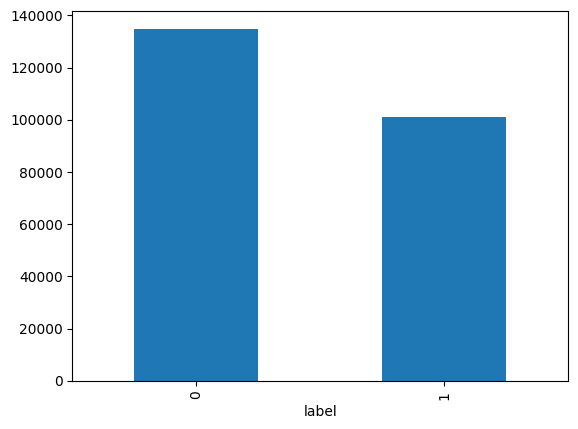

In [9]:
#Let's check for imbalance in our dataset
df['label'].value_counts().plot(kind='bar')

The data is balanced, so both classes are well-represented.

In [10]:
#Summary statistics
df.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.428105
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,0.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


The dataset has significant variance across its features as each column has a distinct range and distribution. Numerical features like URLLength and URLSimilarityIndex have wide ranges and high variability, while binary features such as IsDomainIP and HasCopyrightInfo are more consistent.

The variability we saw on the previous graph differs a lot among all the features, we will need to scale our data for PCA.

## 2. Data Preprocessing

In [11]:
#Let's check for missing values
df.isnull().sum()

URLLength                     0
DomainLength                  0
IsDomainIP                    0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
DomainTitleMatchScore         0
URLTitleMatchScore            0
HasFavicon                    0
Robots                        0
IsResponsive                  0
NoOfURLRedirect               0
NoOfSelf

There are no missing values in our dataset.
As for the outliers, we will not remove any of them as they may represent phishing attempts.
Phishing URLs are often designed to deviate from normal patterns (e.g., very long URLs, excessive special characters).

## 3. Data Exploration

### Correlations + Heatmap

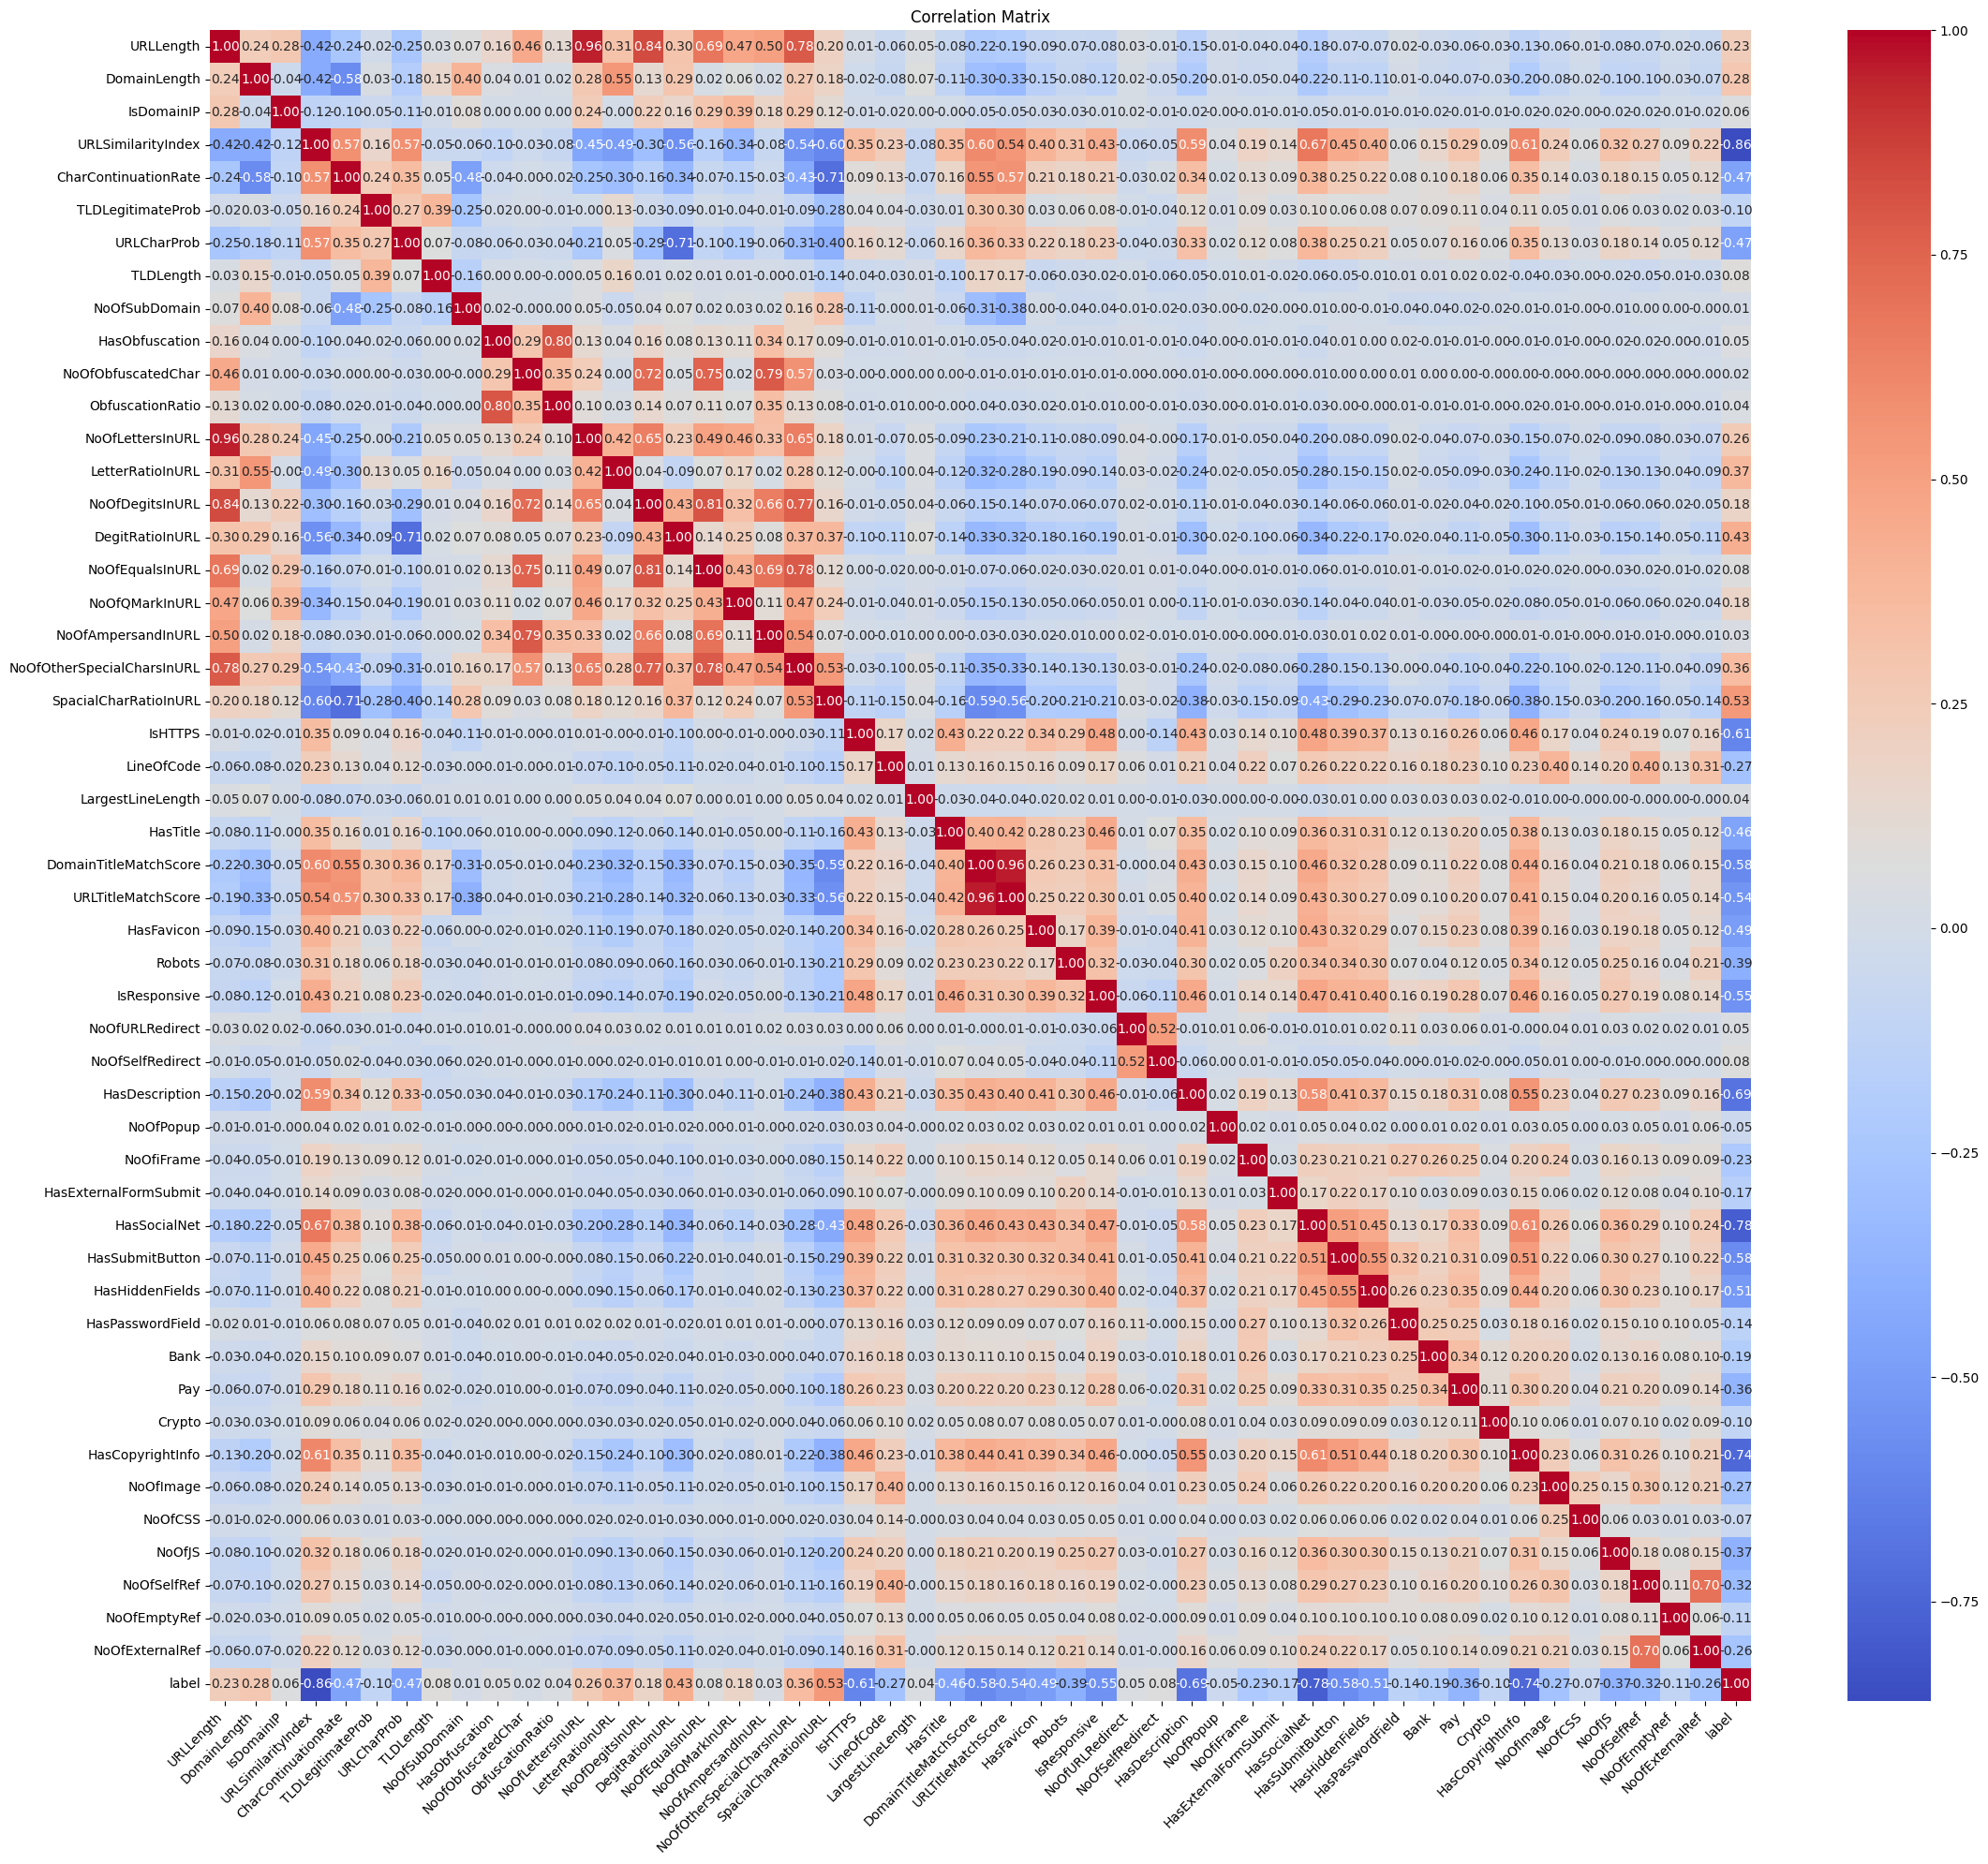

In [12]:
#Let's vizualize correlations using a heatmap 
plt.figure(figsize=(23, 20))  # Increase the figure size
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", annot_kws={"size": 10})  # Adjust annotation size
plt.title("Correlation Matrix")  # Larger title
plt.xticks(rotation=45, ha="right", fontsize=10)  # Rotate x-axis labels for better readability
plt.yticks(fontsize=10)  # Adjust y-axis label size
plt.tight_layout()  # Prevent clipping
plt.show()

From this heatmap, we can tell that the following features have a strong correlation with the labels:
- "URLSimilarityIndex" (0.86)
- "HasSocialNet" (0.78)
- "HasCopyrightInfo" (0.74)
So, these features are significant in predicting whether the website is phishing or legit.

### PCA

In [13]:
#Let's perform Principal Component Analysis (PCA)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#Let's standardize our data first
X = df.drop(columns=["label"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

#Explained variance ratio
ratio = pca.explained_variance_ratio_

#Cumulative variance explained
cum_var = np.cumsum(ratio)

#Find the number of components to explain 96% variance
n = np.argmax(cum_var >= 0.96) + 1
print(f"Number of components to explain 96% variance: {n}")

Number of components to explain 96% variance: 38


38 components are needed to explain 96%, which is a lot of features, meaning that the dataset has high dimensionality with variability spread across many features.

In [14]:
#Let's display relative importance of principal components
for i, variance in enumerate(ratio):
    print(f"Principal Component {i+1}: {variance:.4f}")

Principal Component 1: 0.1835
Principal Component 2: 0.1000
Principal Component 3: 0.0544
Principal Component 4: 0.0410
Principal Component 5: 0.0374
Principal Component 6: 0.0362
Principal Component 7: 0.0319
Principal Component 8: 0.0297
Principal Component 9: 0.0276
Principal Component 10: 0.0247
Principal Component 11: 0.0228
Principal Component 12: 0.0223
Principal Component 13: 0.0214
Principal Component 14: 0.0201
Principal Component 15: 0.0199
Principal Component 16: 0.0195
Principal Component 17: 0.0190
Principal Component 18: 0.0176
Principal Component 19: 0.0173
Principal Component 20: 0.0168
Principal Component 21: 0.0155
Principal Component 22: 0.0150
Principal Component 23: 0.0146
Principal Component 24: 0.0136
Principal Component 25: 0.0133
Principal Component 26: 0.0129
Principal Component 27: 0.0123
Principal Component 28: 0.0120
Principal Component 29: 0.0116
Principal Component 30: 0.0112
Principal Component 31: 0.0108
Principal Component 32: 0.0104
Principal Compone

PC1 explains 18.35% of the total variance, and PC2 - 10%.
These two combined capture the largest trends in the dataset.

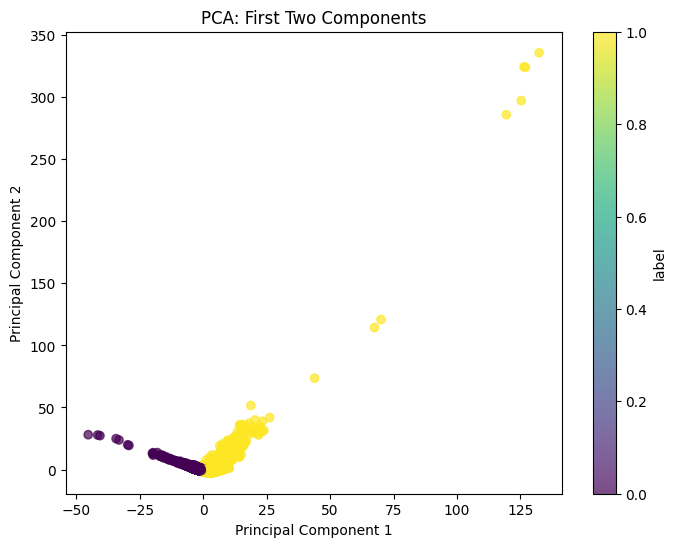

In [15]:
#Let's plot the first two principal components
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["label"], cmap="viridis", alpha=0.7)
plt.colorbar(label="label")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: First Two Components")
plt.show()

There appears to be a clear clustering in the data. Points to the left and near the origin belong to one class, legitimate URLs, while those farther to the right or higher along PC2 belong to another class, phishing URLs. This clustering suggests that the data is separable along the first two principal components, which is useful for classification tasks.

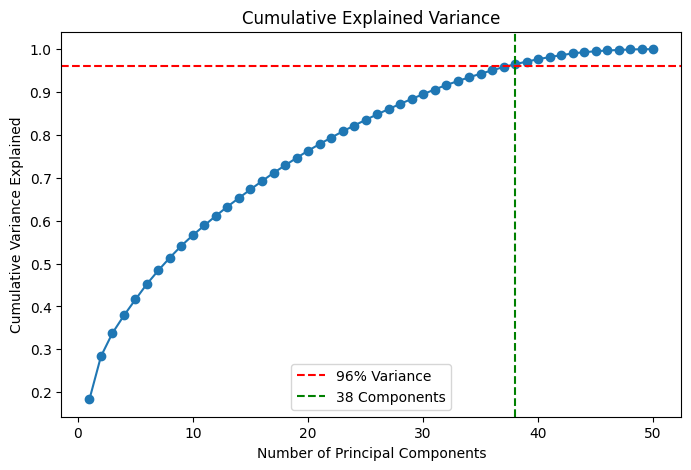

In [16]:
#Let's plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(y=0.96, color="r", linestyle="--", label="96% Variance")
plt.axvline(x=n, color="g", linestyle="--", label=f"{n} Components")
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained")
plt.legend()
plt.show()

We see that:
- the first 10 components explain ~55% of variability
- the first 20 - around 75%
- the first 38 - 96%.
This means that the rest, 12 components, contribute very little variance and are not critical for understanding the dataset.

### Decision Trees

Training Accuracy: 1.0
Testing Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     27035
           1       1.00      1.00      1.00     20124

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



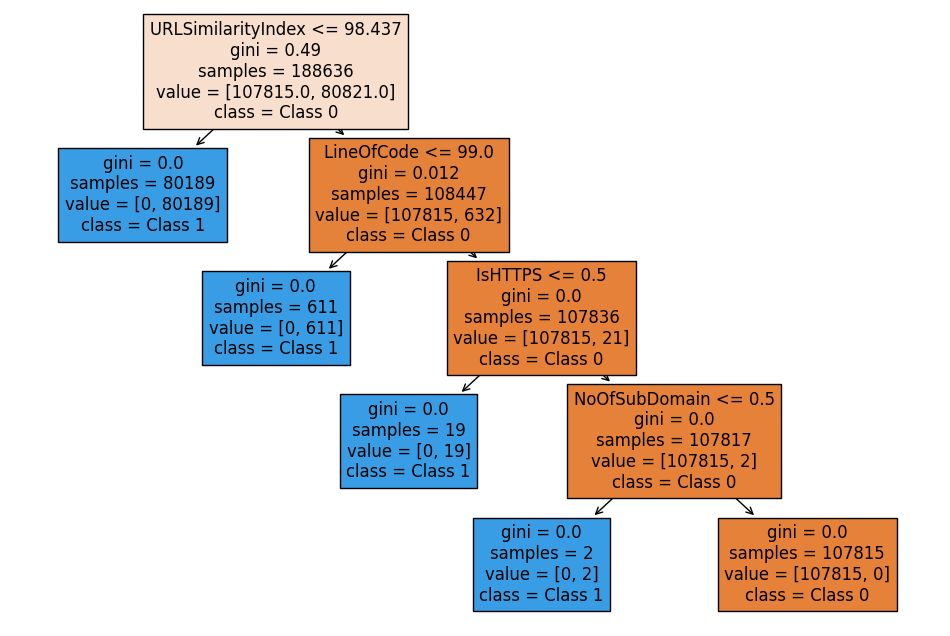

                       Feature  Importance
3           URLSimilarityIndex    0.986398
22                  LineOfCode    0.013147
21                     IsHTTPS    0.000411
8                NoOfSubDomain    0.000043
0                    URLLength    0.000000
37             HasSubmitButton    0.000000
29                IsResponsive    0.000000
30             NoOfURLRedirect    0.000000
31            NoOfSelfRedirect    0.000000
32              HasDescription    0.000000
33                   NoOfPopup    0.000000
34                  NoOfiFrame    0.000000
35       HasExternalFormSubmit    0.000000
36                HasSocialNet    0.000000
39            HasPasswordField    0.000000
38             HasHiddenFields    0.000000
27                  HasFavicon    0.000000
40                        Bank    0.000000
41                         Pay    0.000000
42                      Crypto    0.000000
43            HasCopyrightInfo    0.000000
44                   NoOfImage    0.000000
45         

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, classification_report

X = df.drop(columns=["label"])  
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tree = DecisionTreeClassifier(random_state=42, max_depth=5)
tree.fit(X_train, y_train)

y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))

plt.figure(figsize=(12, 8))
plot_tree(tree, feature_names=X.columns, class_names=["Class 0", "Class 1"], filled=True)
plt.show()

feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
}).sort_values(by="Importance", ascending=False)
print(feature_importances)

The results are suspiciously good. However, we saw from the heatmap previously that labels had the highest correlation with URLSimilarityIndex, meaning that this feature was the most significant to our model.

Despite the small max depth, the model could still overfit to the training data. So, let's do the cross-validation to ensure it generalizes across different splits of the dataset:

In [18]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree, X, y, cv=5)
print("Cross-Validation Accuracy:", scores.mean())

Cross-Validation Accuracy: 1.0


Cross-validation is also good, so our data is not overfitting.
That is why I looked into the initial research. I found out that they collected the data and derived the "URLSimilarityIndex" themselves, based on the formula that is using calculations between a source URL and a target URL. Their research is actually called "phishing URL detection framework based on similarity index". So, the results are actually exceptional because scholars have come up with a formula that would make the prediction of phishing websites 100% precise.

Let's drop the columns the scholars have derived themselves and work with the raw data instead.

Training Accuracy: 0.9818857482134905
Testing Accuracy: 0.982293941771454
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98     27035
           1       0.98      0.98      0.98     20124

    accuracy                           0.98     47159
   macro avg       0.98      0.98      0.98     47159
weighted avg       0.98      0.98      0.98     47159



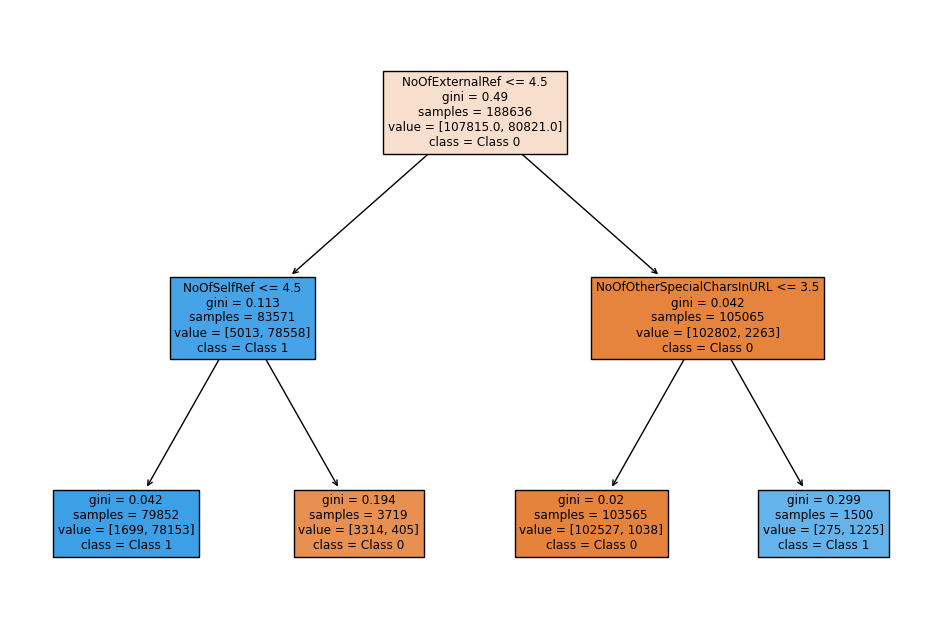

                       Feature  Importance
44             NoOfExternalRef    0.914938
42                 NoOfSelfRef    0.062645
15  NoOfOtherSpecialCharsInURL    0.022417
33             HasHiddenFields    0.000000
25             NoOfURLRedirect    0.000000
26            NoOfSelfRedirect    0.000000
27              HasDescription    0.000000
28                   NoOfPopup    0.000000
29                  NoOfiFrame    0.000000
30       HasExternalFormSubmit    0.000000
31                HasSocialNet    0.000000
32             HasSubmitButton    0.000000
34            HasPasswordField    0.000000
23                      Robots    0.000000
35                        Bank    0.000000
36                         Pay    0.000000
37                      Crypto    0.000000
38            HasCopyrightInfo    0.000000
39                   NoOfImage    0.000000
40                     NoOfCSS    0.000000
41                      NoOfJS    0.000000
43                NoOfEmptyRef    0.000000
24         

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, classification_report

X = df.drop(columns=["label", "URLSimilarityIndex", "CharContinuationRate", "URLTitleMatchScore", "URLCharProb", "TLDLegitimateProb"])  
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tree = DecisionTreeClassifier(random_state=42, max_depth=2)
tree.fit(X_train, y_train)

y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))

plt.figure(figsize=(12, 8))
plot_tree(tree, feature_names=X.columns, class_names=["Class 0", "Class 1"], filled=True)
plt.show()

feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
}).sort_values(by="Importance", ascending=False)
print(feature_importances)

In [20]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree, X, y, cv=5)
print("Cross-Validation Accuracy:", scores.mean())

Cross-Validation Accuracy: 0.9819673869250833


After deleting the derived by scholars features, the scores in the classification report and the cross-validation accuracy - all of these are still really good. Now we see that NoOfExternalRef is the most important feature in differentiating phishing websites.

## 4. Experimental Method

### Random Forest

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

#Step 1: Feature Selection
X = df.drop(columns=["label", "URLSimilarityIndex", "CharContinuationRate", "URLTitleMatchScore", "URLCharProb", "TLDLegitimateProb"])
y = df["label"]  

#Step 2: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Step 3: Random Forest Classifier
rf = RandomForestClassifier(random_state=42, n_estimators=100)

#Step 4: Cross-Validation
cv_scores = cross_val_score(rf, X_train, y_train, cv=5)
print("Cross-Validation Accuracy (Random Forest):", cv_scores.mean())

#Step 5: Train and Evaluate
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Testing Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

#Log feature importances
feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)
print("Feature Importances:\n", feature_importances)

Cross-Validation Accuracy (Random Forest): 0.9998515660351105
Testing Accuracy: 0.9998939756992302
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     27035
           1       1.00      1.00      1.00     20124

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

Feature Importances:
                        Feature  Importance
18                  LineOfCode    0.159590
44             NoOfExternalRef    0.155216
42                 NoOfSelfRef    0.133750
39                   NoOfImage    0.111838
40                     NoOfCSS    0.061259
31                HasSocialNet    0.058060
41                      NoOfJS    0.057420
38            HasCopyrightInfo    0.043167
27              HasDescription    0.031409
19           LargestLineLength    0.031229
15  NoOfOtherSpecialCharsInURL    0.028672
17          

Both, testing and cross-validation accuracy scores, are 99.9%. Compared to the last decision tree that was made, here the feature importance is more spread out. Previously the most significant feature was NoOfExternalRef at 98%, while here its importance is equivalent to 15% only. No tuning is needed.

### AdaBoost

In [28]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

#Step 1: Split the data
X = df.drop(columns=["label", "URLSimilarityIndex", "CharContinuationRate", "URLTitleMatchScore", "URLCharProb", "TLDLegitimateProb"])
y = df["label"]  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Step 2: Initialize and train the AdaBoost classifier
#Using a simple Decision Tree as the base estimator
base_est = DecisionTreeClassifier(max_depth=1, random_state=42)
adaboost = AdaBoostClassifier(estimator=base_est, n_estimators=50, algorithm="SAMME", random_state=42)

#Train the AdaBoost model
adaboost.fit(X_train, y_train)

#Step 3: Evaluate the model
y_pred = adaboost.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, adaboost.predict(X_train)))
print("Testing Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

#Step 4: Cross-validation score
cv_scores = cross_val_score(adaboost, X_train, y_train, cv=5)
print("Cross-Validation Accuracy (AdaBoost):", cv_scores.mean())

#Feature importance
feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": adaboost.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Feature Importances:\n", feature_importances)

Training Accuracy: 0.9995228906465362
Testing Accuracy: 0.9993638541953815
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     27035
           1       1.00      1.00      1.00     20124

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

Cross-Validation Accuracy (AdaBoost): 0.9993320461744123
Feature Importances:
                        Feature  Importance
17                     IsHTTPS    0.160754
18                  LineOfCode    0.123466
19           LargestLineLength    0.119853
44             NoOfExternalRef    0.109004
15  NoOfOtherSpecialCharsInURL    0.093276
4                NoOfSubDomain    0.079553
42                 NoOfSelfRef    0.077023
11             DegitRatioInURL    0.060994
9             LetterRatioInURL    0.050227
31                HasSocialNet    0.026855
27              HasDes

Applying AdaBoost resulted in 99.93% testing and cross-validation accuracy scores. No further modifications are needed.

### MLP

In [29]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

#Step 1: Split the data
X = df.drop(columns=["label", "URLSimilarityIndex", "CharContinuationRate", "URLTitleMatchScore", "URLCharProb", "TLDLegitimateProb"]) 
y = df["label"] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Step 2: Scale the data
scaler = StandardScaler()

#Fit on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Step 3: Initialize and train the MLP classifier
mlp = MLPClassifier(hidden_layer_sizes=(100, 50),  # Two hidden layers with 100 and 50 neurons
                     activation='relu',            # Activation function
                     solver='adam',                # Optimizer
                     max_iter=200,                 # Maximum iterations
                     random_state=42)

#Train the MLP model
mlp.fit(X_train_scaled, y_train)

#Step 4: Evaluate the model
y_pred = mlp.predict(X_test_scaled)

print("Training Accuracy:", accuracy_score(y_train, mlp.predict(X_train_scaled)))
print("Testing Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

#Step 5: Cross-validation score
cv_scores = cross_val_score(mlp, X_train_scaled, y_train, cv=5)
print("Cross-Validation Accuracy (MLP):", cv_scores.mean())

Training Accuracy: 0.9999522890646536
Testing Accuracy: 0.9997455416781527
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     27035
           1       1.00      1.00      1.00     20124

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

Cross-Validation Accuracy (MLP): 0.9998038547063247


The cross-validation accuracy is 99.98%. The classification report shows that the model achieved perfect precision, recall, and F1-scores across both classes.

## 5. Results
Summing up, all the models showed exceptional results with 98%+ scores for all the metrics (accuracy, precision, etc), which could be one of two scenarios:
1) the data is highly separable that makes it incredibly easy to detect phishing websites
2) the dataset is not reliable and some features can contain direct or indirect information about the target variable